In [1]:
Output = '/Users/alexis/Library/CloudStorage/OneDrive-UniversityofNorthCarolinaatChapelHill/CEMALB_DataAnalysisPM/Projects/P1014. Nanoparticles Respiratory Tract/P1014.3. Analyses/P1014.3.2. Volcano Plots/Output'
cur_date = '030326'

library(readxl)
library(openxlsx)
library(writexl)
library(tidyverse)
library(ggrepel)
library(ggsci)

# reading in files
two_group_df = data.frame(read_excel("Input/Two_Group_Results_030426.xlsx"))  

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.5.1
✔ ggplot2   3.5.2     ✔ tibble    3.3.0
✔ lubridate 1.9.4     ✔ tidyr     1.3.1
✔ purrr     1.1.0     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors


In [2]:
head(two_group_df)

,ELISA_ID,UniProt_ID,Protein_Name,Comparison,log2FC,P.Value,P.Adj
,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>
1,nEL03731,P10909,CLU,Control vs. PET 0.05mg/mL,-1.1552479,1.560646e-10,4.369808e-08
2,nEL04021,O00300,TNFRSF11B,Control vs. PET 0.05mg/mL,-1.0388131,6.836962e-09,9.571747e-07
3,nEL00061,P10147,CCL3,Control vs. PET 0.05mg/mL,0.4542374,6.971455e-07,6.506691e-05
4,nEL08971,Q99538,LGMN,Control vs. PET 0.05mg/mL,-0.2389893,3.140006e-04,1.989901e-02
5,nEL01981,Q99988,GDF-15 (MIC-1),Control vs. PET 0.05mg/mL,0.2398895,3.864820e-04,1.989901e-02
6,nEL03101,Q15389,Angiopoietin-1,Control vs. PET 0.05mg/mL,-0.2430584,4.264074e-04,1.989901e-02


Creating a volcano plot to differences in protein expression after exposure to phthalates and nylon.

In [4]:
get_significance = function(df){
    # adding a col to denote whether a protein had a significant p value, log FC, or both
    
    # add a column of NAs
    df$diffexpressed <- "No Significance"
    
    # if p adj is significant only
    df$diffexpressed[df$P.Adj < 0.05] <- "Significant"#"P Adjust Only"
    
    # if logFoldChange > log2(1.5) and p adj < 0.05, set as "significant" 
    #df$diffexpressed[abs(df$log2FC) > log2(1.5) & df$P.Adj < 0.05] <- "P Adjust and log Fold Change"
    
    # making into a factor
    df$diffexpressed = factor(df$diffexpressed, levels = c("No Significance", "Significant"))#"P Adjust Only", 
                                                                           #"P Adjust and log Fold Change"))

    return(df)
}

# calling fn
two_sig_protein_df = get_significance(two_group_df)
two_sig_protein_df$Comparison = factor(two_sig_protein_df$Comparison, 
                                       levels = c('Control vs. PET 0.05mg/mL','Control vs. PET 0.1mg/mL',
                                                  'PET 0.05mg/mL vs. PET 0.1mg/mL', 'Control vs. PET-Rhodamine B 0.05mg/mL',
                                                  'Control vs. PET-Rhodamine B 0.1mg/mL', 
                                                  'PET-Rhodamine B 0.05mg/mL vs.\nPET-Rhodamine B 0.1mg/mL'))

head(two_sig_protein_df)

,ELISA_ID,UniProt_ID,Protein_Name,Comparison,log2FC,P.Value,P.Adj,diffexpressed
,<chr>,<chr>,<chr>,<fct>,<dbl>,<dbl>,<dbl>,<fct>
1,nEL03731,P10909,CLU,Control vs. PET 0.05mg/mL,-1.1552479,1.560646e-10,4.369808e-08,Significant
2,nEL04021,O00300,TNFRSF11B,Control vs. PET 0.05mg/mL,-1.0388131,6.836962e-09,9.571747e-07,Significant
3,nEL00061,P10147,CCL3,Control vs. PET 0.05mg/mL,0.4542374,6.971455e-07,6.506691e-05,Significant
4,nEL08971,Q99538,LGMN,Control vs. PET 0.05mg/mL,-0.2389893,3.140006e-04,1.989901e-02,Significant
5,nEL01981,Q99988,GDF-15 (MIC-1),Control vs. PET 0.05mg/mL,0.2398895,3.864820e-04,1.989901e-02,Significant
6,nEL03101,Q15389,Angiopoietin-1,Control vs. PET 0.05mg/mL,-0.2430584,4.264074e-04,1.989901e-02,Significant


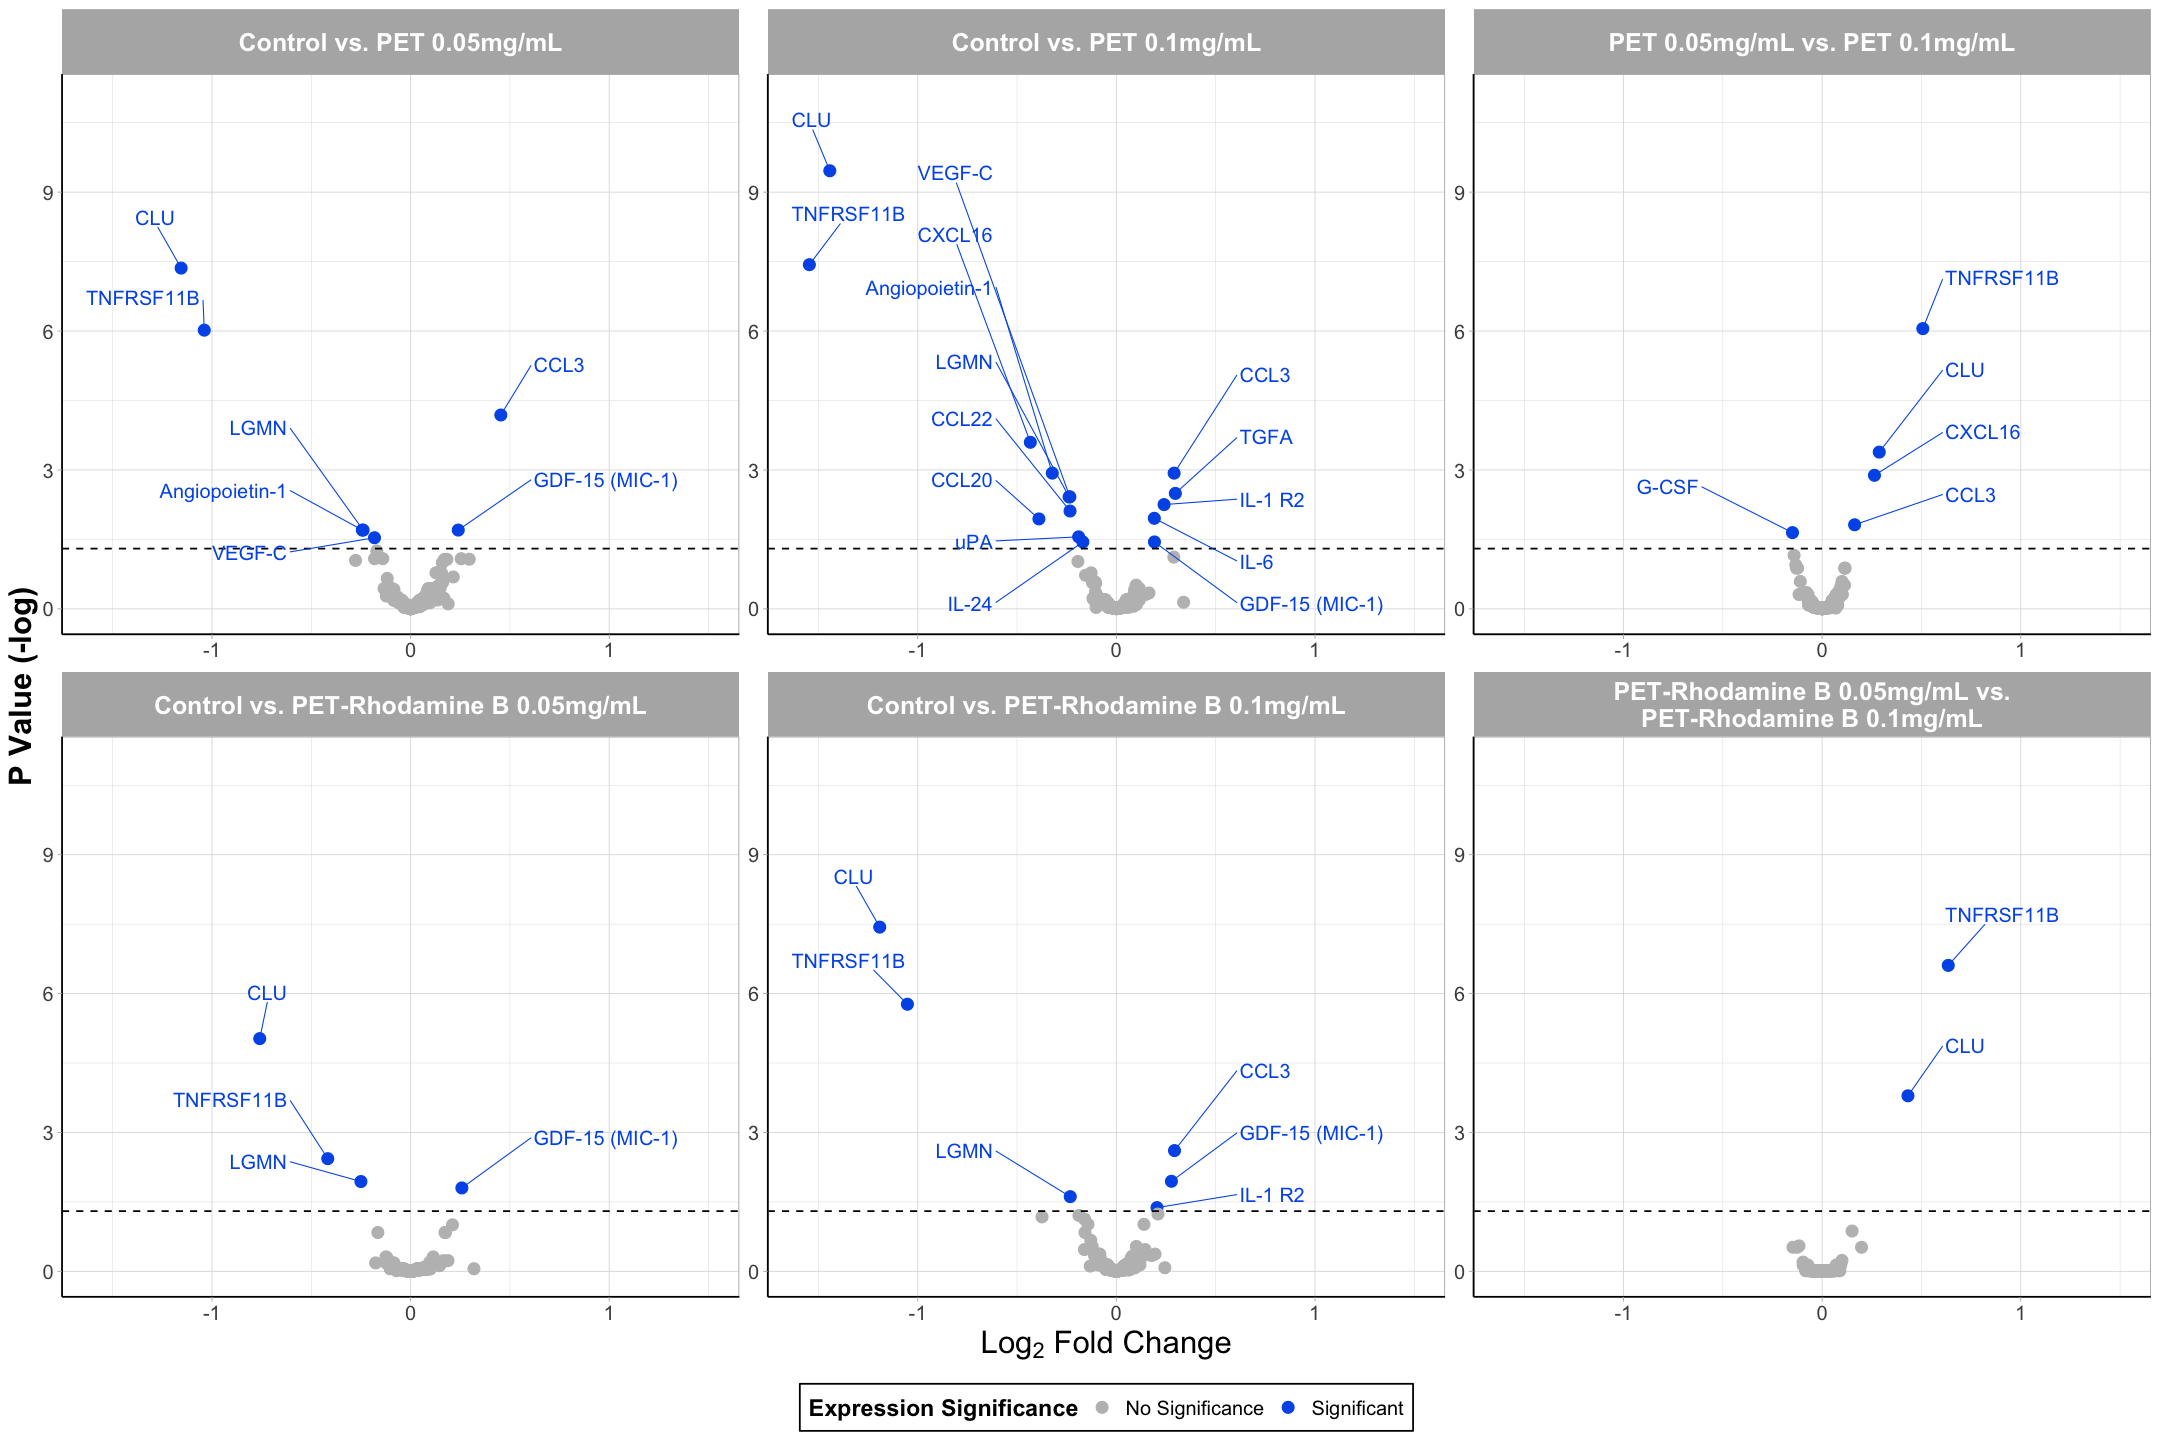

In [9]:
options(repr.plot.width=18, repr.plot.height=12) #changing size

lancet_palette = pal_lancet()(2)

ggplot() + 
  geom_point(data = two_sig_protein_df, aes(x = log2FC, y = -log10(P.Adj), color = diffexpressed), size = 3) + 

  # P Value line
  geom_hline(yintercept = -log10(0.05), linetype = "dashed") + 
  # # FC Line
  # geom_vline(xintercept = log2(1.5), linetype = "dashed") +
  # geom_vline(xintercept = -log2(1.5), linetype = "dashed") +

  # changing x limits of what is visible in the plot
    xlim(-1.6, 1.5) + 
    ylim(0, 11) + 

  geom_text_repel(data = two_sig_protein_df %>%
                  filter(log2FC > 0, P.Adj < 0.05),
                  aes(x = log2FC, y = -log10(P.Adj), label = Protein_Name, color = diffexpressed),
                  hjust = 'right', direction = 'y', nudge_y = 1.1, nudge_x = 0.03, xlim = c(0.5, NA), 
                  segment.size = 0.3, box.padding = 1, max.overlaps = Inf, size = 4.2, show.legend = FALSE) + 
 geom_text_repel(data = two_sig_protein_df %>%
                  filter(log2FC < 0 & log2FC > -1, P.Adj < 0.05), 
                  aes(x = log2FC, y = -log10(P.Adj), label = Protein_Name, color = diffexpressed), 
                  hjust = 'left', direction = 'y', nudge_y = 1, nudge_x = -0.03, xlim = c(NA, -0.5), 
                 segment.size = 0.3, box.padding = 1, max.overlaps = Inf, size = 4.2, show.legend = FALSE) + 
 geom_text_repel(data = two_sig_protein_df %>%
                  filter(log2FC < -1, P.Adj < 0.05), 
                  aes(x = log2FC, y = -log10(P.Adj), label = Protein_Name, color = diffexpressed), 
                  hjust = 'right', direction = 'y', nudge_y = 1.1, nudge_x = -0.03, xlim = c(NA, -0.5), 
                 segment.size = 0.3, box.padding = 1, max.overlaps = Inf, size = 4.2, show.legend = FALSE) + 

  facet_wrap(~Comparison, scales = 'free') + 

  theme_light() + 
  theme(axis.line = element_line(colour = "black"), #making x and y axes black
        axis.text = element_text(size = 12), #changing size of x axis labels
        axis.title = element_text(face = "bold", size = rel(1.7)), #changes axis titles
        legend.title = element_text(face = 'bold', size = 14), #changes legend title
        legend.text = element_text(size = 12), #changes legend text
        legend.position = "bottom", # changing legend position
        legend.background = element_rect(colour = 'black', fill = 'white', linetype = 'solid'),
        strip.text.x = element_text(size = 15, face = "bold"), #changes size of facet x axis 
        strip.text.y = element_text(size = 15, face = "bold")) + #changes size of facet y axis 
  labs(x = expression(Log[2]*" Fold Change"), y = 'P Value (-log)') +

  scale_color_manual(name = "Expression Significance",
                      values = c("gray", "#005BEA",'#F0D25E', "#005BEA"))